In [ ]:
import os
import random
import sys
import cv2
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split


importer les donnes

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
folder_path="/content/drive/MyDrive/projet ia/mini_projet/data"


In [ ]:
classes=["Healthy","olive_peacock_spot"]
dataset=[]
for class_name in classes:
  class_path=os.path.join(folder_path,class_name)
  label_index=classes.index(class_name)
  for img_file in tqdm(os.listdir(class_path)):
    img_path=os.path.join(class_path,img_file)
    img=cv2.imread(img_path)
    if img is not None:
      img=cv2.resize(img,(224,224))
      dataset.append((img,label_index))


100%|██████████| 1460/1460 [00:41<00:00, 35.26it/s] 


In [ ]:
len(dataset)

2510

In [ ]:
dataset

[(array([[[195, 200, 201],
          [195, 200, 201],
          [197, 202, 203],
          ...,
          [200, 207, 210],
          [199, 205, 210],
          [197, 203, 210]],
  
         [[194, 199, 200],
          [195, 200, 201],
          [197, 202, 203],
          ...,
          [200, 207, 210],
          [199, 205, 210],
          [197, 203, 210]],
  
         [[192, 198, 199],
          [195, 200, 201],
          [197, 202, 203],
          ...,
          [200, 207, 210],
          [199, 205, 210],
          [197, 203, 210]],
  
         ...,
  
         [[176, 181, 184],
          [178, 183, 186],
          [179, 184, 187],
          ...,
          [191, 196, 199],
          [191, 196, 199],
          [190, 195, 198]],
  
         [[176, 181, 184],
          [178, 183, 186],
          [179, 184, 187],
          ...,
          [192, 197, 200],
          [188, 194, 197],
          [190, 195, 198]],
  
         [[176, 181, 184],
          [178, 183, 186],
          [179, 184, 187

array([[[ 50,  64,  58],
        [ 51,  65,  59],
        [ 53,  67,  61],
        ...,
        [123, 144, 135],
        [119, 140, 132],
        [118, 139, 130]],

       [[ 48,  62,  56],
        [ 50,  64,  58],
        [ 52,  66,  60],
        ...,
        [124, 145, 136],
        [122, 143, 134],
        [119, 140, 131]],

       [[ 50,  64,  58],
        [ 54,  68,  62],
        [ 54,  68,  63],
        ...,
        [125, 146, 137],
        [124, 145, 136],
        [121, 142, 133]],

       ...,

       [[ 50,  57,  54],
        [ 53,  60,  57],
        [ 52,  59,  56],
        ...,
        [112, 133, 122],
        [112, 133, 121],
        [107, 130, 117]],

       [[ 50,  57,  54],
        [ 53,  60,  57],
        [ 54,  61,  58],
        ...,
        [111, 133, 121],
        [109, 131, 119],
        [105, 127, 115]],

       [[ 50,  57,  54],
        [ 53,  60,  57],
        [ 52,  59,  56],
        ...,
        [110, 132, 120],
        [110, 132, 120],
        [105, 127, 115]]], dtype=uint8)
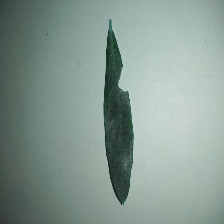

In [ ]:
img


normalisation

In [ ]:
x_images=[]
y_images=[]
for img,label in tqdm(dataset):
  x_images.append(img)
  y_images.append(label)

x=np.array(x_images) / 255
y=np.array(y_images)

100%|██████████| 2510/2510 [00:00<00:00, 2204292.93it/s]


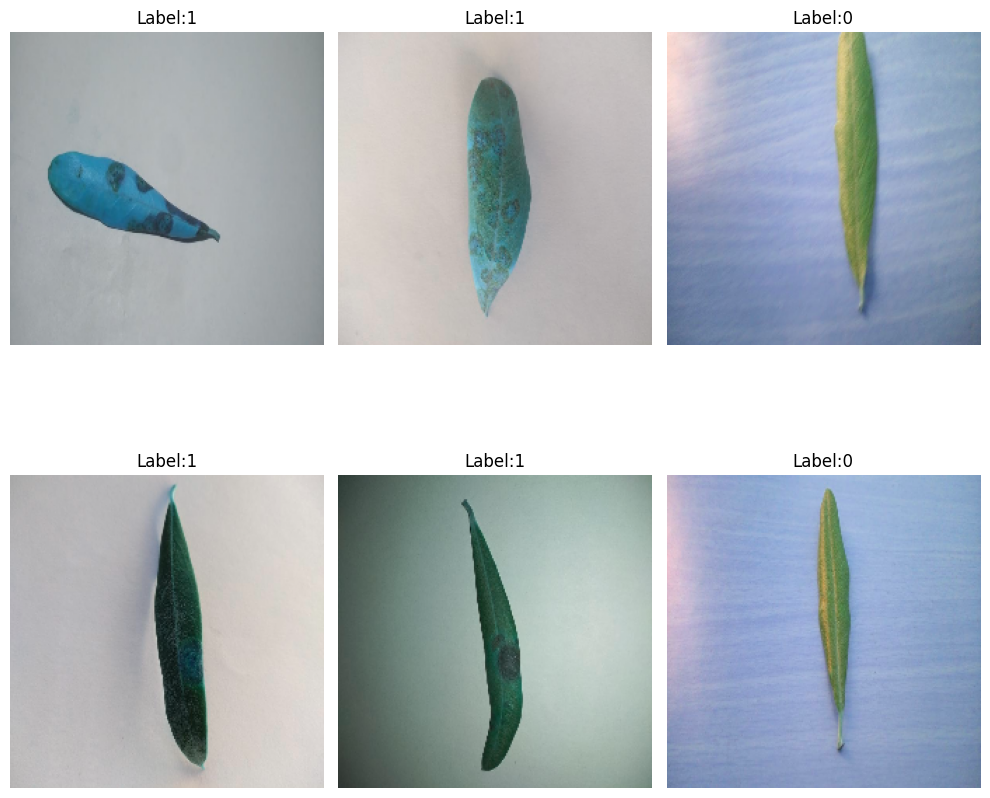

In [ ]:
num_samples=6
random_samples=np.random.choice(len(x),num_samples,replace=False)

fig,axes=plt.subplots(2,3,figsize=(10,10))
for i,idx in enumerate(random_samples):
  ax=axes[i//3,i%3]
  ax.imshow(x[idx],cmap='gray')
  ax.set_title(f"Label:{y[idx]}")
  ax.axis('off')

plt.tight_layout()
plt.show()


decouper data train/test


In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
x_train.shape

(2008, 224, 224, 3)

In [ ]:
x_test.shape

(502, 224, 224, 3)

entrainment du cnn

In [ ]:
model=Sequential()
model.add(Conv2D(100,(3,3),activation='relu',input_shape=(224,224,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(100,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(100,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())
model.add(Dense(32,activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1,activation='sigmoid'))

model.summary()



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 100)  │         2,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 100)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 100)  │        90,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 100)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 100)    │        90,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 100)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 67600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │     2,163,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,346,265 (8.95 MB)

 Trainable params: 2,346,265 (8.95 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])

In [ ]:
history=model.fit(x_train,y_train,epochs=20,validation_data=(x_test,y_test))

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 381s 6s/step - accuracy: 0.5734 - loss: 0.8043 - val_accuracy: 0.8147 - val_loss: 0.3552
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 384s 6s/step - accuracy: 0.7873 - loss: 0.4014 - val_accuracy: 0.8287 - val_loss: 0.3438
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 371s 6s/step - accuracy: 0.8479 - loss: 0.3402 - val_accuracy: 0.8526 - val_loss: 0.3201
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 371s 6s/step - accuracy: 0.8846 - loss: 0.3149 - val_accuracy: 0.8506 - val_loss: 0.2882
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 381s 6s/step - accuracy: 0.8850 - loss: 0.2870 - val_accuracy: 0.8446 - val_loss: 0.3008
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 367s 6s/step - accuracy: 0.8762 - loss: 0.3071 - val_accuracy: 0.8526 - val_loss: 0.3022
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 368s 6s/step - accuracy: 0.8744 - loss: 0.2969 - val_accuracy: 0.8426 - val_loss: 0.2985
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 372s 6s/step - accuracy: 0.8975 - loss: 0.2775 - val_accuracy: 0.8466 - v

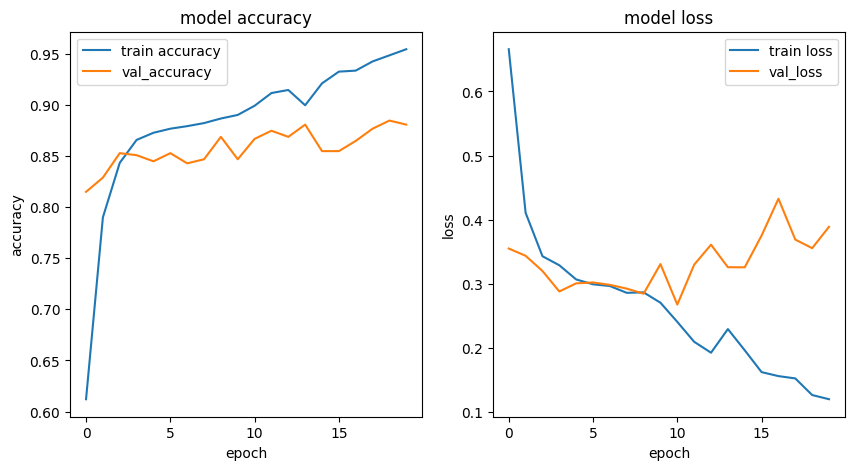

In [ ]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],label='train accuracy')
plt.plot(history.history['val_accuracy'],label='val_accuracy')
plt.title('model accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'],label='train loss')
plt.plot(history.history['val_loss'],label='val_loss')
plt.title('model loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()

plt.show()

In [ ]:
# Sauvegarde model entier (architecture + poids)
model.save("/content/drive/MyDrive/projet_ia/mini_projet/peacock_model.h5")